<a href="https://colab.research.google.com/github/Joancarmya/Deep-Learning/blob/main/DL_Lab3__CNN_CIFAR_10_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


In [3]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

In [4]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

y_train_raw = y_train_raw.flatten()
y_test_raw = y_test_raw.flatten()

print("CIFAR-10 dataset loaded successfully using tf.keras.datasets!")
print("Training images shape:", X_train_raw.shape, "| Training labels shape:", y_train_raw.shape)
print("Testing images shape :", X_test_raw.shape, "| Testing labels shape :", y_test_raw.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2627s 15us/step
CIFAR-10 dataset loaded successfully using tf.keras.datasets!
Training images shape: (50000, 32, 32, 3) | Training labels shape: (50000,)
Testing images shape : (10000, 32, 32, 3) | Testing labels shape : (10000,)


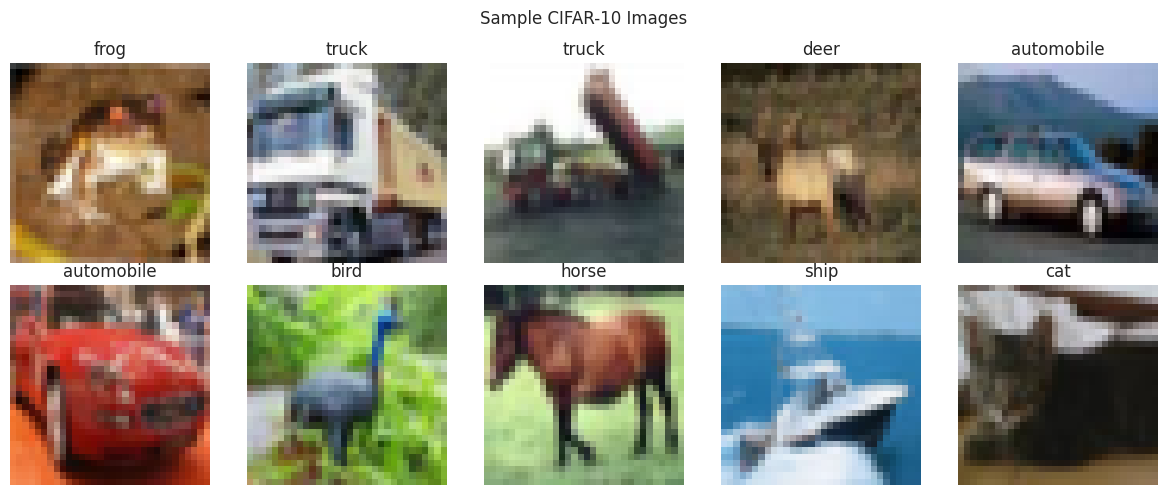

In [5]:
import matplotlib.pyplot as plt

# ---- Ten Sample Images ----
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i])
    plt.title(CLASS_NAMES[y_train_raw[i]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

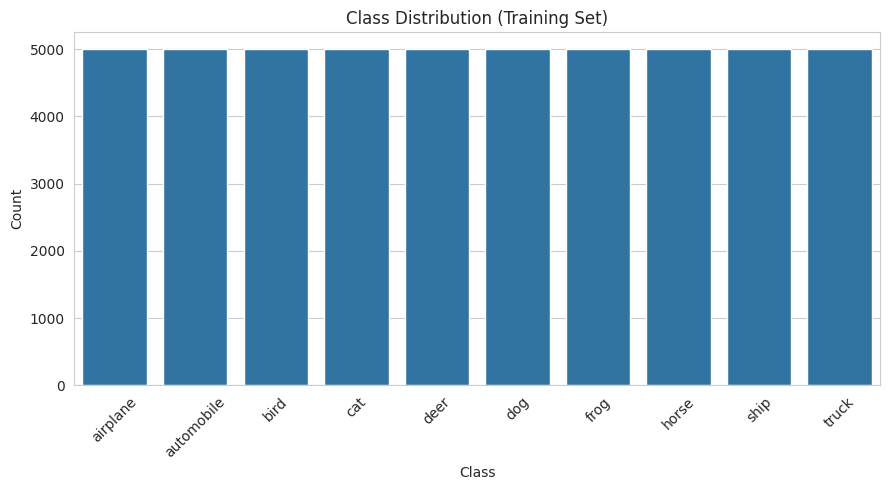

Class-wise counts:
0    5000
1    5000
2    5000
3    5000
4    5000
5    5000
6    5000
7    5000
8    5000
9    5000
Name: count, dtype: int64


In [6]:
# ---- Class Distribution ----
plt.figure(figsize=(9, 5))
sns.countplot(x=y_train_raw)
plt.xticks(ticks=range(10), labels=CLASS_NAMES, rotation=45)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Training Set)")
plt.tight_layout()
plt.show()

print("Class-wise counts:")
print(pd.Series(y_train_raw).value_counts().sort_index())

In [7]:
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

y_train_cat = to_categorical(y_train_raw, num_classes=10)
y_test_cat = to_categorical(y_test_raw, num_classes=10)

print("X_train:", X_train.shape, X_train.dtype, "| min/max:", X_train.min(), X_train.max())
print("X_test :", X_test.shape, X_test.dtype)
print("y_train (one-hot):", y_train_cat.shape)

X_train: (50000, 32, 32, 3) float32 | min/max: 0.0 1.0
X_test : (10000, 32, 32, 3) float32
y_train (one-hot): (50000, 10)


In [8]:
sample_image = X_train[0:1]  # shape (1, 32, 32, 3), batch of one
N = 32  # input size

kernel_sizes = [3, 5, 7]
print(f"{'Kernel Size':<15}{'Formula Output':<20}{'Actual Conv2D Output':<25}")
for F in kernel_sizes:
    formula_output = (N - F + 2*0) // 1 + 1  # P=0, S=1
    conv_layer = layers.Conv2D(filters=8, kernel_size=F, strides=1, padding="valid")
    feature_map = conv_layer(sample_image)
    print(f"{F}x{F:<13}{formula_output}x{formula_output:<17}{feature_map.shape[1]}x{feature_map.shape[2]}")

Kernel Size    Formula Output      Actual Conv2D Output     
3x3            30x30               30x30
5x5            28x28               28x28
7x7            26x26               26x26


In [9]:
F = 3  # fixed kernel size for this comparison
configs = [
    {"stride": 1, "padding": "valid"},
    {"stride": 2, "padding": "valid"},
    {"stride": 1, "padding": "same"},
    {"stride": 2, "padding": "same"},
]

print(f"{'Stride':<10}{'Padding':<10}{'Formula Output':<18}{'Actual Output':<15}")
for cfg in configs:
    S = cfg["stride"]
    if cfg["padding"] == "valid":
        P = 0
        formula_output = (N - F + 2*P) // S + 1
    else:  # "same" padding keeps output = ceil(N / S)
        formula_output = int(np.ceil(N / S))

    conv_layer = layers.Conv2D(filters=8, kernel_size=F, strides=S, padding=cfg["padding"])
    feature_map = conv_layer(sample_image)

    print(f"{S:<10}{cfg['padding']:<10}{formula_output}x{formula_output:<14}{feature_map.shape[1]}x{feature_map.shape[2]}")

Stride    Padding   Formula Output    Actual Output  
1         valid     30x30            30x30
2         valid     15x15            15x15
1         same      32x32            32x32
2         same      16x16            16x16


Feature map tensor shape: (1, 32, 32, 16)


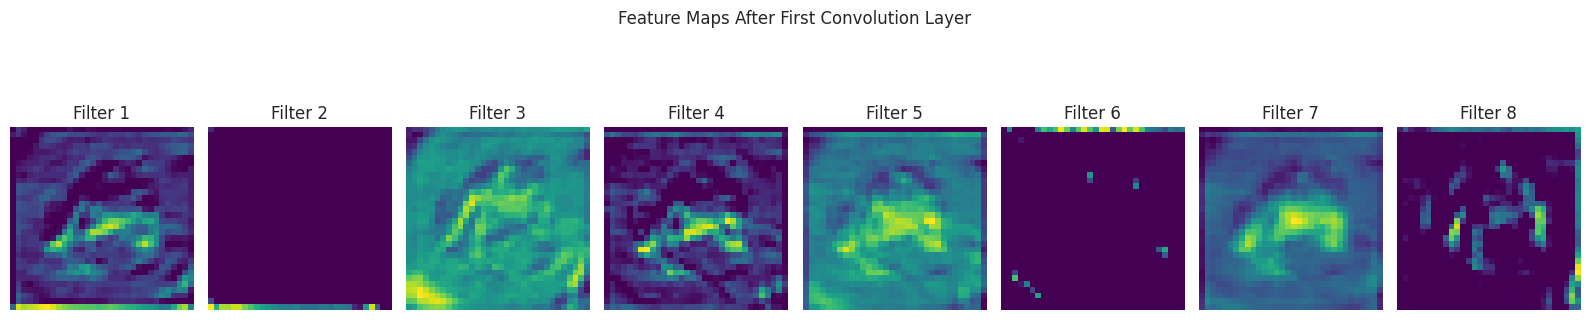

In [10]:
# ---- Task 4: Feature Map Visualization ----
feature_extractor = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(filters=16, kernel_size=3, activation="relu", padding="same")
])

feature_maps = feature_extractor.predict(sample_image, verbose=0)
print("Feature map tensor shape:", feature_maps.shape)  # (1, 32, 32, 16)

n_maps_to_show = 8
plt.figure(figsize=(16, 4))
for i in range(n_maps_to_show):
    plt.subplot(1, n_maps_to_show, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.title(f"Filter {i+1}")
    plt.axis("off")
plt.suptitle("Feature Maps After First Convolution Layer")
plt.tight_layout()
plt.show()

In [11]:
# ---- Output size comparison on a single feature map ----
pool_input = feature_maps  # reuse the (1, 32, 32, 16) feature maps from Task 4 above

max_pool = layers.MaxPooling2D(pool_size=2)(pool_input)
avg_pool = layers.AveragePooling2D(pool_size=2)(pool_input)

print("Input to pooling shape :", pool_input.shape)
print("Max Pooling output shape:", max_pool.shape)
print("Average Pooling output shape:", avg_pool.shape)

Input to pooling shape : (1, 32, 32, 16)
Max Pooling output shape: (1, 16, 16, 16)
Average Pooling output shape: (1, 16, 16, 16)


In [12]:
def build_small_cnn(pooling="max"):
    PoolLayer = layers.MaxPooling2D if pooling == "max" else layers.AveragePooling2D
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        PoolLayer(2),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        PoolLayer(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

POOL_COMPARISON_EPOCHS = 8  # reduced from 20 purely for speed in this side-by-side comparison

results_pooling = {}
for pooling_type in ["max", "average"]:
    print(f"\nTraining CNN with {pooling_type} pooling...")
    m = build_small_cnn(pooling=pooling_type)
    start = time.time()
    hist = m.fit(X_train, y_train_cat, validation_split=0.1,
                 epochs=POOL_COMPARISON_EPOCHS, batch_size=32, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = m.evaluate(X_test, y_test_cat, verbose=0)
    results_pooling[pooling_type] = {"test_acc": test_acc, "time": elapsed, "history": hist}
    print(f"{pooling_type.capitalize()} Pooling -> Test Accuracy: {test_acc:.4f} | Training Time: {elapsed:.2f}s")


Training CNN with max pooling...
Max Pooling -> Test Accuracy: 0.6768 | Training Time: 466.76s

Training CNN with average pooling...
Average Pooling -> Test Accuracy: 0.6378 | Training Time: 311.02s


In [13]:
# ---- Task 6: Build the required CNN ----
def build_main_cnn(conv_filters=(16, 32)):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(conv_filters[0], kernel_size=3, padding="same"),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(conv_filters[1], kernel_size=3, padding="same"),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model

main_model = build_main_cnn(conv_filters=(16, 32))
main_model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
main_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,874 (534.66 KB)

 Trainable params: 136,874 (534.66 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
start_time = time.time()
main_history = main_model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
main_training_time = time.time() - start_time
print(f"\nTotal training time: {main_training_time:.2f} seconds")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - accuracy: 0.4534 - loss: 1.5182 - val_accuracy: 0.5640 - val_loss: 1.2471
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - accuracy: 0.5944 - loss: 1.1515 - val_accuracy: 0.6268 - val_loss: 1.0634
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.6454 - loss: 1.0090 - val_accuracy: 0.6548 - val_loss: 0.9905
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.6778 - loss: 0.9243 - val_accuracy: 0.6638 - val_loss: 0.9615
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.7012 - loss: 0.8615 - val_accuracy: 0.6764 - val_loss: 0.9295
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 32ms/step - accuracy: 0.7204 - loss: 0.8088 - val_accuracy: 0.6838 - val_loss: 0.9236
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 32ms/step - accuracy: 0.7362 - loss: 0.7626 - val_accuracy: 0.6840 - val_loss: 0.9302
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.7502 -

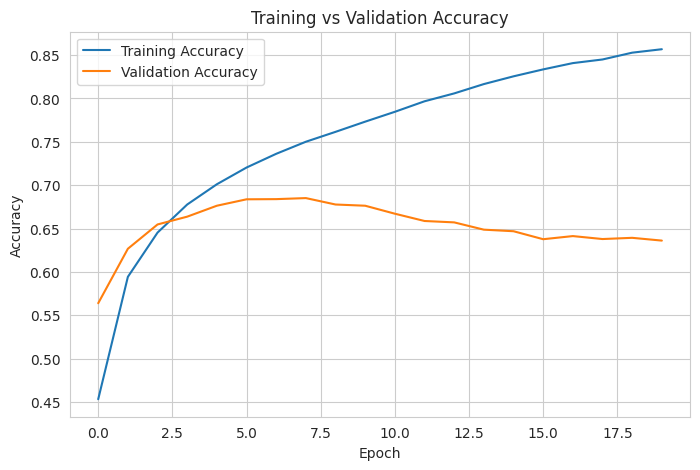

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(main_history.history["accuracy"], label="Training Accuracy")
plt.plot(main_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

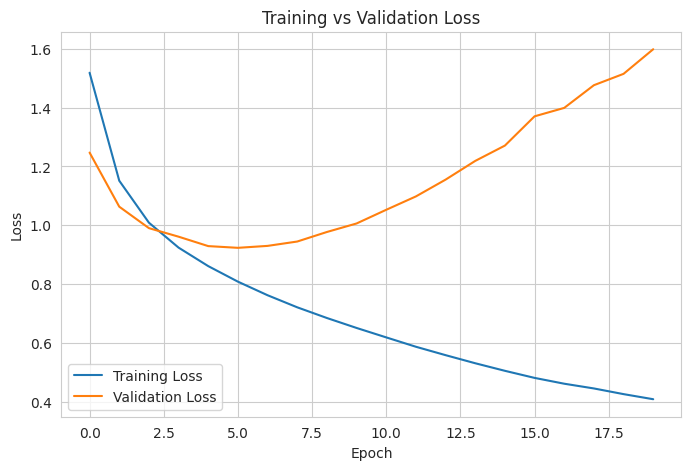

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(main_history.history["loss"], label="Training Loss")
plt.plot(main_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [17]:
y_pred_probs = main_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average="macro")
test_recall = recall_score(y_true, y_pred, average="macro")
test_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-score  : {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

train_accuracy = main_history.history["accuracy"][-1]
print(f"\nFinal Training Accuracy: {train_accuracy:.4f}")

total_params = main_model.count_params()
print(f"Total Trainable Parameters: {total_params:,}")

Test Accuracy  : 0.6284
Test Precision : 0.6285
Test Recall    : 0.6284
Test F1-score  : 0.6201

Classification Report:
              precision    recall  f1-score   support

    airplane       0.63      0.71      0.67      1000
  automobile       0.70      0.83      0.76      1000
        bird       0.44      0.59      0.51      1000
         cat       0.52      0.32      0.39      1000
        deer       0.66      0.42      0.51      1000
         dog       0.60      0.49      0.54      1000
        frog       0.66      0.76      0.71      1000
       horse       0.65      0.72      0.69      1000
        ship       0.67      0.77      0.72      1000
       truck       0.73      0.68      0.71      1000

    accuracy                           0.63     10000
   macro avg       0.63      0.63      0.62     10000
weighted avg       0.63      0.63      0.62     10000


Final Training Accuracy: 0.8568
Total Trainable Parameters: 136,874


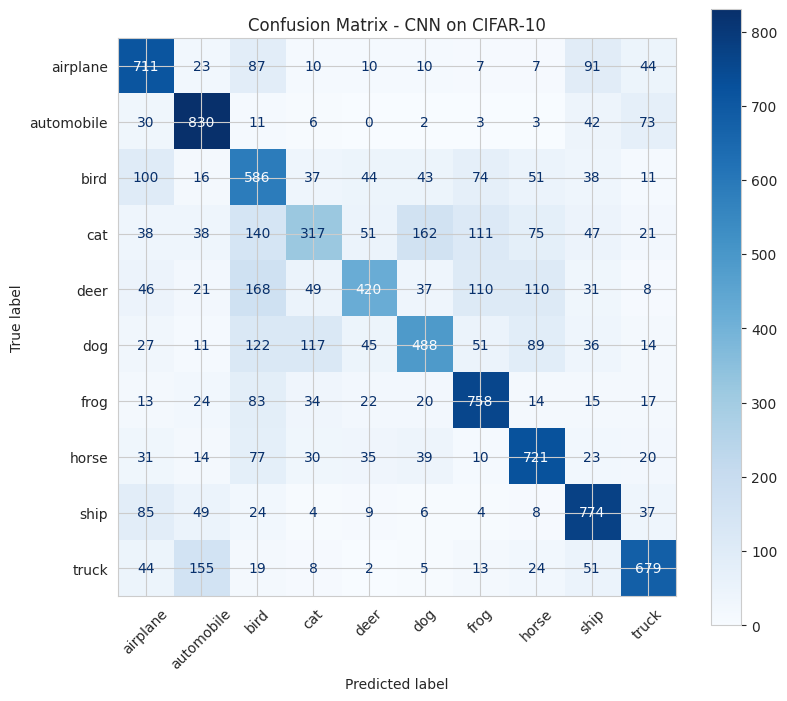

In [18]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", xticks_rotation=45, ax=plt.gca())
plt.title("Confusion Matrix - CNN on CIFAR-10")
plt.show()

In [19]:
N_ex, F_ex, S_ex, P_ex = 64, 5, 2, 2
output_size = (N_ex - F_ex + 2*P_ex) // S_ex + 1
print(f"Input: {N_ex}x{N_ex}, Kernel: {F_ex}x{F_ex}, Stride: {S_ex}, Padding: {P_ex}")
print(f"Output size = ({N_ex} - {F_ex} + 2x{P_ex}) / {S_ex} + 1 = {output_size}x{output_size}")

# Verify with an actual Conv2D layer using explicit ZeroPadding2D + valid convolution
verify_input = np.random.rand(1, N_ex, N_ex, 3).astype("float32")
padded = layers.ZeroPadding2D(padding=P_ex)(verify_input)
verify_layer = layers.Conv2D(filters=4, kernel_size=F_ex, strides=S_ex, padding="valid")
verify_output = verify_layer(padded)
print(f"Verified actual output shape: {verify_output.shape[1]}x{verify_output.shape[2]}")

Input: 64x64, Kernel: 5x5, Stride: 2, Padding: 2
Output size = (64 - 5 + 2x2) / 2 + 1 = 32x32
Verified actual output shape: 32x32


In [20]:
filters_ex2 = 64
kernel_ex2 = 3
input_channels_ex2 = 3  # RGB

params = (kernel_ex2 * kernel_ex2 * input_channels_ex2 + 1) * filters_ex2
print(f"Parameters = (kernel_h x kernel_w x input_channels + 1) x filters")
print(f"           = ({kernel_ex2} x {kernel_ex2} x {input_channels_ex2} + 1) x {filters_ex2}")
print(f"           = {params}")

# Verify with an actual Conv2D layer
verify_conv = layers.Conv2D(filters=filters_ex2, kernel_size=kernel_ex2, input_shape=(32, 32, 3))
verify_conv.build((None, 32, 32, 3))
print(f"Verified actual parameter count: {verify_conv.count_params()}")

Parameters = (kernel_h x kernel_w x input_channels + 1) x filters
           = (3 x 3 x 3 + 1) x 64
           = 1792
Verified actual parameter count: 1792


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


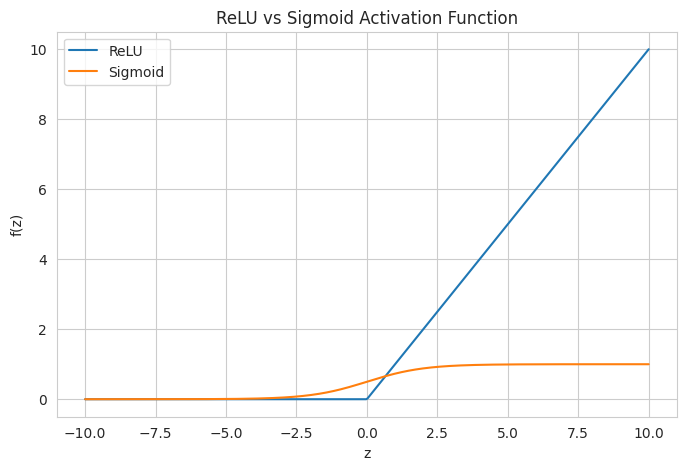

In [21]:
z = np.linspace(-10, 10, 400)
relu_output = np.maximum(0, z)
sigmoid_output = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, relu_output, label="ReLU")
plt.plot(z, sigmoid_output, label="Sigmoid")
plt.xlabel("z")
plt.ylabel("f(z)")
plt.title("ReLU vs Sigmoid Activation Function")
plt.legend()
plt.grid(True)
plt.show()


Training CNN with relu activation...
RELU -> Test Accuracy: 0.6597

Training CNN with sigmoid activation...
SIGMOID -> Test Accuracy: 0.5048


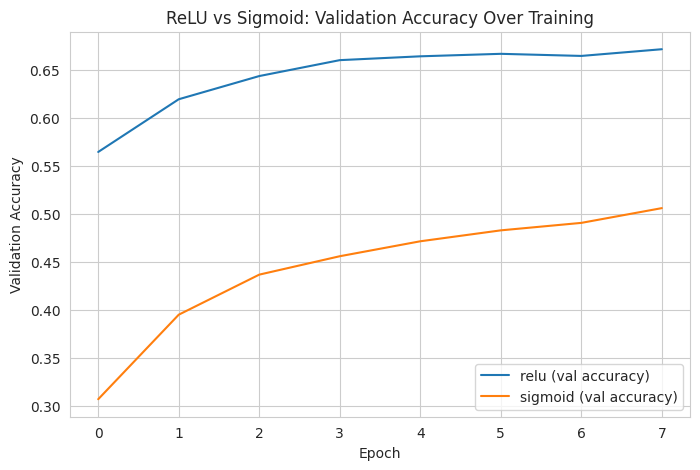

In [22]:
def build_activation_test_cnn(activation="relu"):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, 3, activation=activation, padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation=activation, padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

ACTIVATION_TEST_EPOCHS = 8  # reduced from 20 purely for speed in this comparison

activation_results = {}
for act in ["relu", "sigmoid"]:
    print(f"\nTraining CNN with {act} activation...")
    m = build_activation_test_cnn(activation=act)
    hist = m.fit(X_train, y_train_cat, validation_split=0.1,
                 epochs=ACTIVATION_TEST_EPOCHS, batch_size=32, verbose=0)
    test_loss, test_acc = m.evaluate(X_test, y_test_cat, verbose=0)
    activation_results[act] = {"test_acc": test_acc, "history": hist}
    print(f"{act.upper()} -> Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(8, 5))
for act, res in activation_results.items():
    plt.plot(res["history"].history["val_accuracy"], label=f"{act} (val accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ReLU vs Sigmoid: Validation Accuracy Over Training")
plt.legend()
plt.show()

Reusing the Task 5 max-pooling vs average-pooling comparison:

Max Pooling -> Test Accuracy: 0.6768 | Training Time: 466.76s
Average Pooling -> Test Accuracy: 0.6378 | Training Time: 311.02s


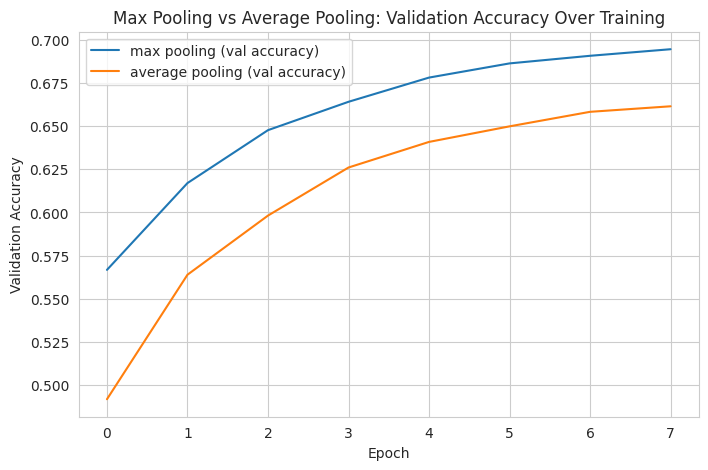

In [23]:
print("Reusing the Task 5 max-pooling vs average-pooling comparison:\n")
for pooling_type, res in results_pooling.items():
    print(f"{pooling_type.capitalize()} Pooling -> Test Accuracy: {res['test_acc']:.4f} | Training Time: {res['time']:.2f}s")

plt.figure(figsize=(8, 5))
for pooling_type, res in results_pooling.items():
    plt.plot(res["history"].history["val_accuracy"], label=f"{pooling_type} pooling (val accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Max Pooling vs Average Pooling: Validation Accuracy Over Training")
plt.legend()
plt.show()

In [24]:
FILTER_TEST_EPOCHS = 8  # reduced from 20 purely for speed in this comparison

filter_results = {}
for filter_count in [16, 64]:
    print(f"\nTraining CNN with {filter_count} filters in each conv layer...")
    m = build_main_cnn(conv_filters=(filter_count, filter_count * 2))
    m.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    start = time.time()
    hist = m.fit(X_train, y_train_cat, validation_split=0.1,
                 epochs=FILTER_TEST_EPOCHS, batch_size=32, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = m.evaluate(X_test, y_test_cat, verbose=0)
    filter_results[filter_count] = {"test_acc": test_acc, "time": elapsed,
                                     "params": m.count_params(), "history": hist}
    print(f"{filter_count} filters -> Test Accuracy: {test_acc:.4f} | "
          f"Training Time: {elapsed:.2f}s | Parameters: {m.count_params():,}")

print("\nSummary:")
for filter_count, res in filter_results.items():
    print(f"  {filter_count:>3} filters: Accuracy={res['test_acc']:.4f}, "
          f"Time={res['time']:.2f}s, Params={res['params']:,}")


Training CNN with 16 filters in each conv layer...
16 filters -> Test Accuracy: 0.6596 | Training Time: 464.45s | Parameters: 136,874

Training CNN with 64 filters in each conv layer...
64 filters -> Test Accuracy: 0.6648 | Training Time: 1549.13s | Parameters: 600,650

Summary:
   16 filters: Accuracy=0.6596, Time=464.45s, Params=136,874
   64 filters: Accuracy=0.6648, Time=1549.13s, Params=600,650


In [25]:
results_summary = pd.DataFrame({
    "Metric": ["Training Accuracy", "Testing Accuracy", "Precision (macro)",
               "Recall (macro)", "F1-score (macro)", "Total Parameters", "Training Time (s)"],
    "Value": [round(train_accuracy, 4), round(test_accuracy, 4), round(test_precision, 4),
              round(test_recall, 4), round(test_f1, 4), f"{total_params:,}",
              round(main_training_time, 2)]
})
display(results_summary)

,Metric,Value
0,Training Accuracy,0.8568
1,Testing Accuracy,0.6284
2,Precision (macro),0.6285
3,Recall (macro),0.6284
4,F1-score (macro),0.6201
5,Total Parameters,"136,874"
6,Training Time (s),1205.98
